# Notebook 02: Exploratory Data Analysis & Unsupervised Learning

**Project 4 — End-to-End Machine Learning: LendingClub Loan Default Prediction**

This notebook covers:
1. Overview of the cleaned dataset
2. Target distribution and default rate over time
3. Univariate analysis of key features
4. Bivariate analysis — feature vs. default status
5. Correlation analysis
6. Comparison with rejected loan applications
7. Unsupervised learning — PCA, K-Means, t-SNE
8. Key insights summary

**Input:** `data/cleaned.parquet`  
**No output files** — this notebook is purely analytical.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

print("Libraries loaded.")

Libraries loaded.


## 1. Load & Overview

In [2]:
df = pd.read_parquet('data/cleaned.parquet')
print(f"Shape: {df.shape}")
print(f"\nColumn dtypes:")
print(df.dtypes.value_counts())
print(f"\nNull values: {df.isnull().sum().sum()}")
df.head()

Shape: (1345310, 70)

Column dtypes:
float64           58
str                8
int64              2
datetime64[us]     1
Int64              1
Name: count, dtype: int64



Null values: 0


,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,credit_age_months
0,3600.0,36,13.99,123.03,C,C4,10.0,MORTGAGE,55000.0,Not Verified,...,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,148
1,24700.0,36,11.99,820.28,C,C1,10.0,MORTGAGE,65000.0,Not Verified,...,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,192
2,20000.0,60,10.78,432.66,B,B4,10.0,MORTGAGE,63000.0,Not Verified,...,0.0,100.0,50.0,0.0,0.0,218418.0,18696.0,6200.0,14877.0,184
3,10400.0,60,22.45,289.91,F,F1,3.0,MORTGAGE,104433.0,Source Verified,...,4.0,96.6,60.0,0.0,0.0,439570.0,95768.0,20300.0,88097.0,210
4,11950.0,36,13.44,405.18,C,C3,4.0,RENT,34000.0,Source Verified,...,0.0,100.0,100.0,0.0,0.0,16900.0,12798.0,9400.0,4000.0,338


In [3]:
df.describe().T.round(2)

,count,mean,min,25%,50%,75%,max,std
loan_amnt,1345310.0,14419.972014,500.0,8000.0,12000.0,20000.0,40000.0,8717.050787
term,1345310.0,41.790196,36.0,36.0,36.0,36.0,60.0,10.268321
int_rate,1345310.0,13.239619,5.31,9.75,12.74,15.99,30.99,4.768716
installment,1345310.0,438.075533,4.93,248.48,375.43,580.73,1719.83,261.512604
emp_length,1345310.0,5.61771,0.0,2.0,6.0,10.0,10.0,3.845187
...,...,...,...,...,...,...,...,...
tot_hi_cred_lim,1345310.0,171275.052464,0.0,51645.0,112373.0,243346.0,9999999.0,174096.189935
total_bal_ex_mort,1345310.0,49231.593869,0.0,21464.0,37296.0,61220.0,3408095.0,46952.441521
total_bc_limit,1345310.0,21404.363704,0.0,8000.0,15100.0,27400.0,1105500.0,21206.77856
total_il_high_credit_limit,1345310.0,41608.552941,0.0,15473.25,31681.0,54799.0,2101913.0,42214.383777


## 2. Target Distribution

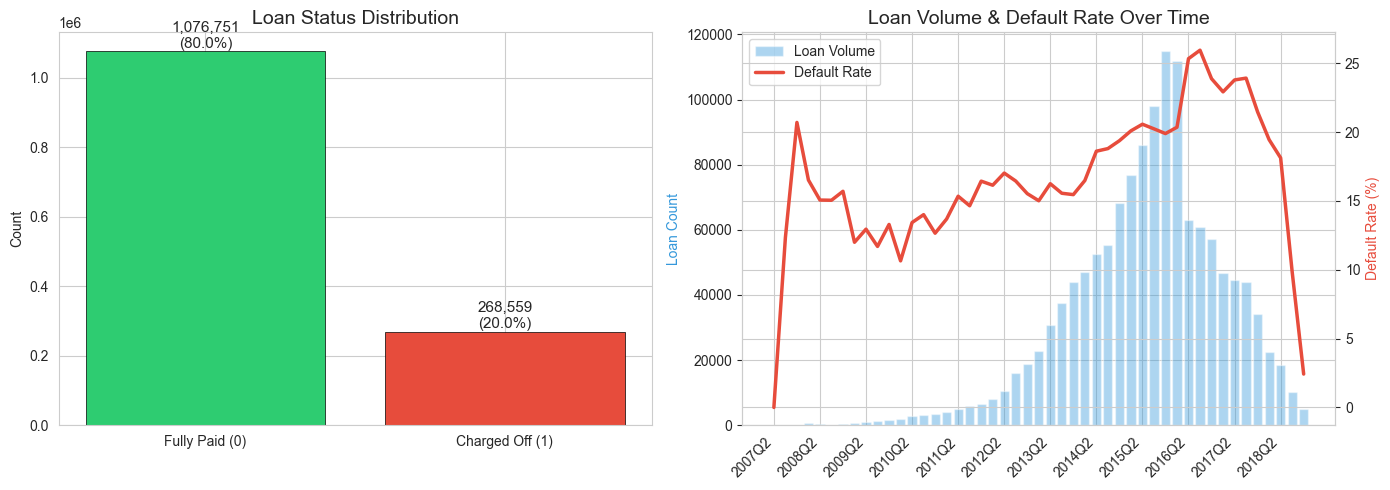

Overall default rate: 19.96%


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot of class distribution
counts = df['loan_status'].value_counts()
labels = ['Fully Paid (0)', 'Charged Off (1)']
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(labels, counts.values, color=colors, edgecolor='black', linewidth=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10000, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=11)
axes[0].set_title('Loan Status Distribution', fontsize=14)
axes[0].set_ylabel('Count')

# Default rate AND loan volume over time (dual axis)
monthly = df.groupby(df['issue_d'].dt.to_period('Q')).agg(
    default_rate=('loan_status', 'mean'),
    count=('loan_status', 'count')
).reset_index()
monthly['issue_d'] = monthly['issue_d'].astype(str)

ax2 = axes[1]
bar_x = range(len(monthly))
ax2.bar(bar_x, monthly['count'], color='#3498db', alpha=0.4, label='Loan Volume')
ax2.set_ylabel('Loan Count', color='#3498db')
ax2.set_xticks(range(0, len(monthly), 4))
ax2.set_xticklabels(monthly['issue_d'].iloc[::4], rotation=45, ha='right')

ax2b = ax2.twinx()
ax2b.plot(bar_x, monthly['default_rate'] * 100, color='#e74c3c', linewidth=2.5, label='Default Rate')
ax2b.set_ylabel('Default Rate (%)', color='#e74c3c')
ax2.set_title('Loan Volume & Default Rate Over Time', fontsize=14)

# Combined legend
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

print(f"Overall default rate: {df['loan_status'].mean():.2%}")

## 3. Univariate Analysis

### 3.1 Key Numerical Features

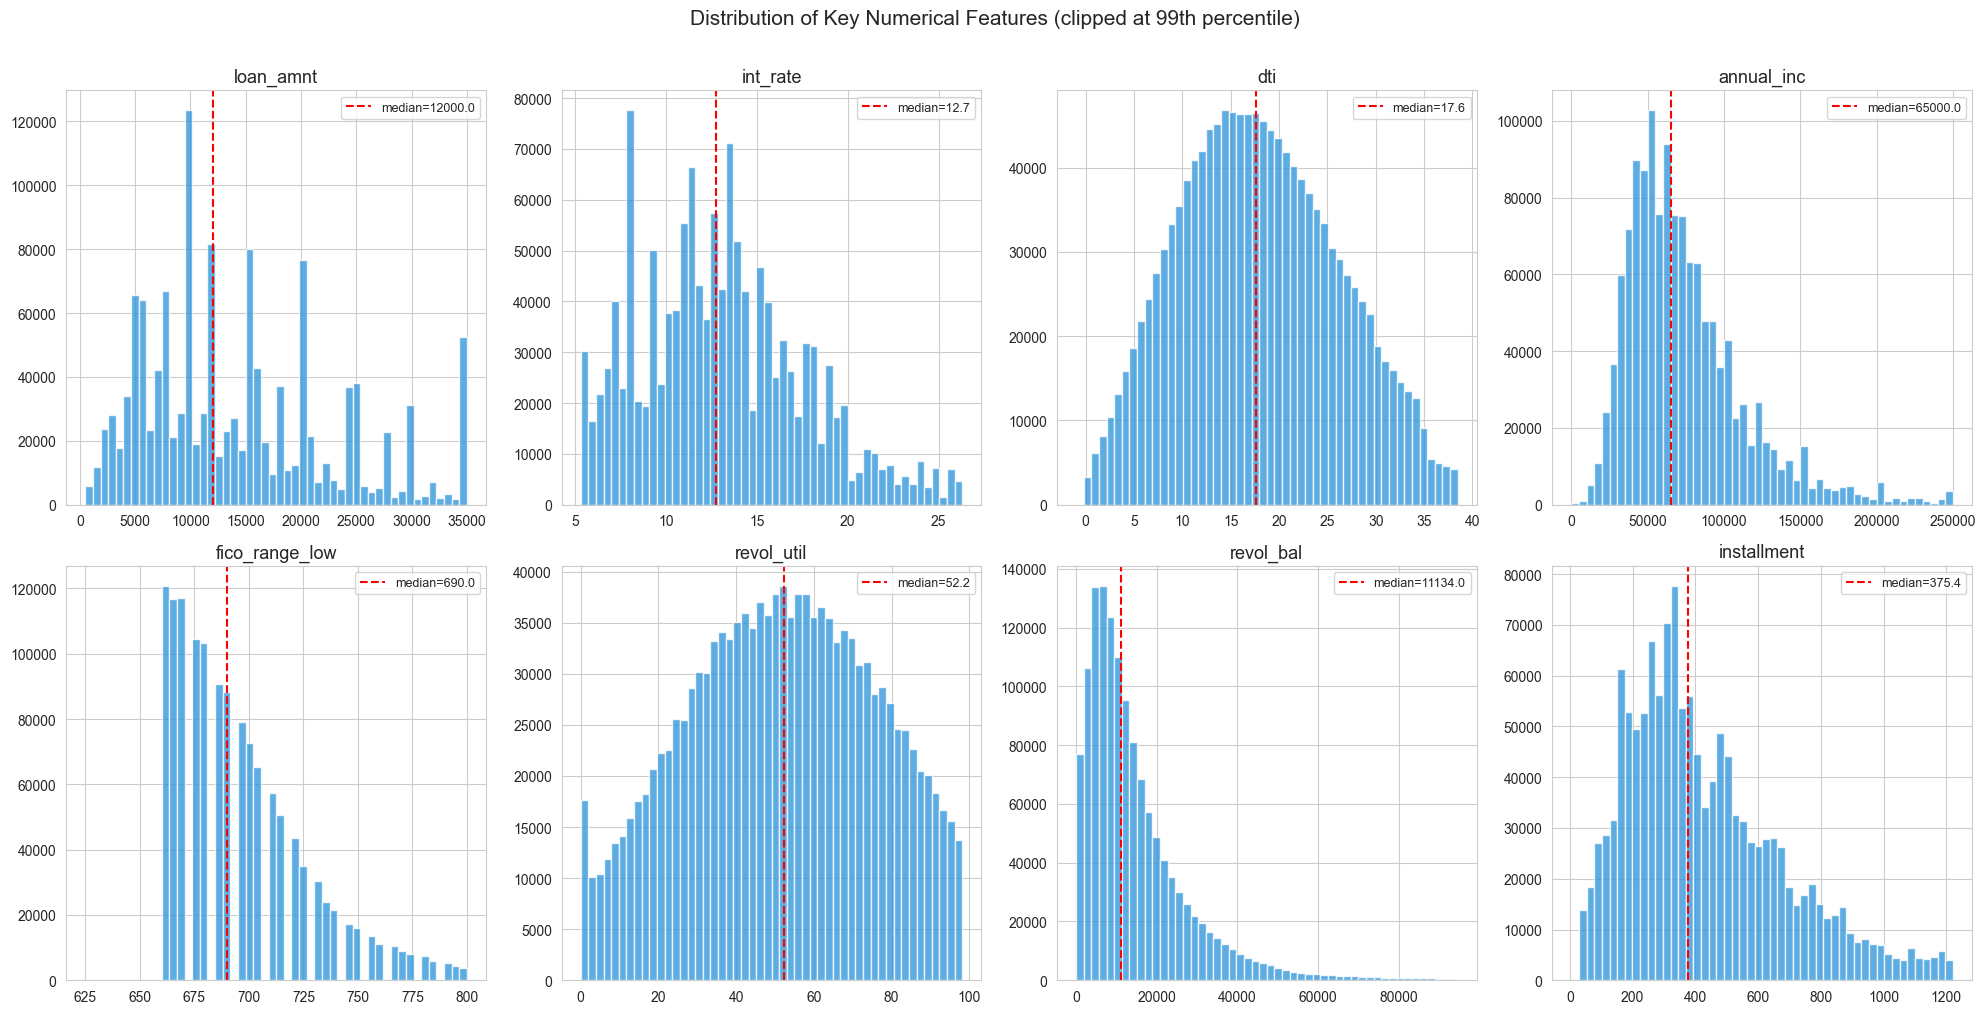

In [5]:
num_features = ['loan_amnt', 'int_rate', 'dti', 'annual_inc',
                'fico_range_low', 'revol_util', 'revol_bal', 'installment']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(num_features):
    data = df[col].dropna()
    # Clip extreme outliers for visualization only
    upper = data.quantile(0.99)
    data_clipped = data[data <= upper]
    axes[i].hist(data_clipped, bins=50, color='#3498db', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=13)
    axes[i].axvline(data.median(), color='red', linestyle='--', label=f'median={data.median():.1f}')
    axes[i].legend(fontsize=9)

plt.suptitle('Distribution of Key Numerical Features (clipped at 99th percentile)', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### 3.2 Key Categorical Features

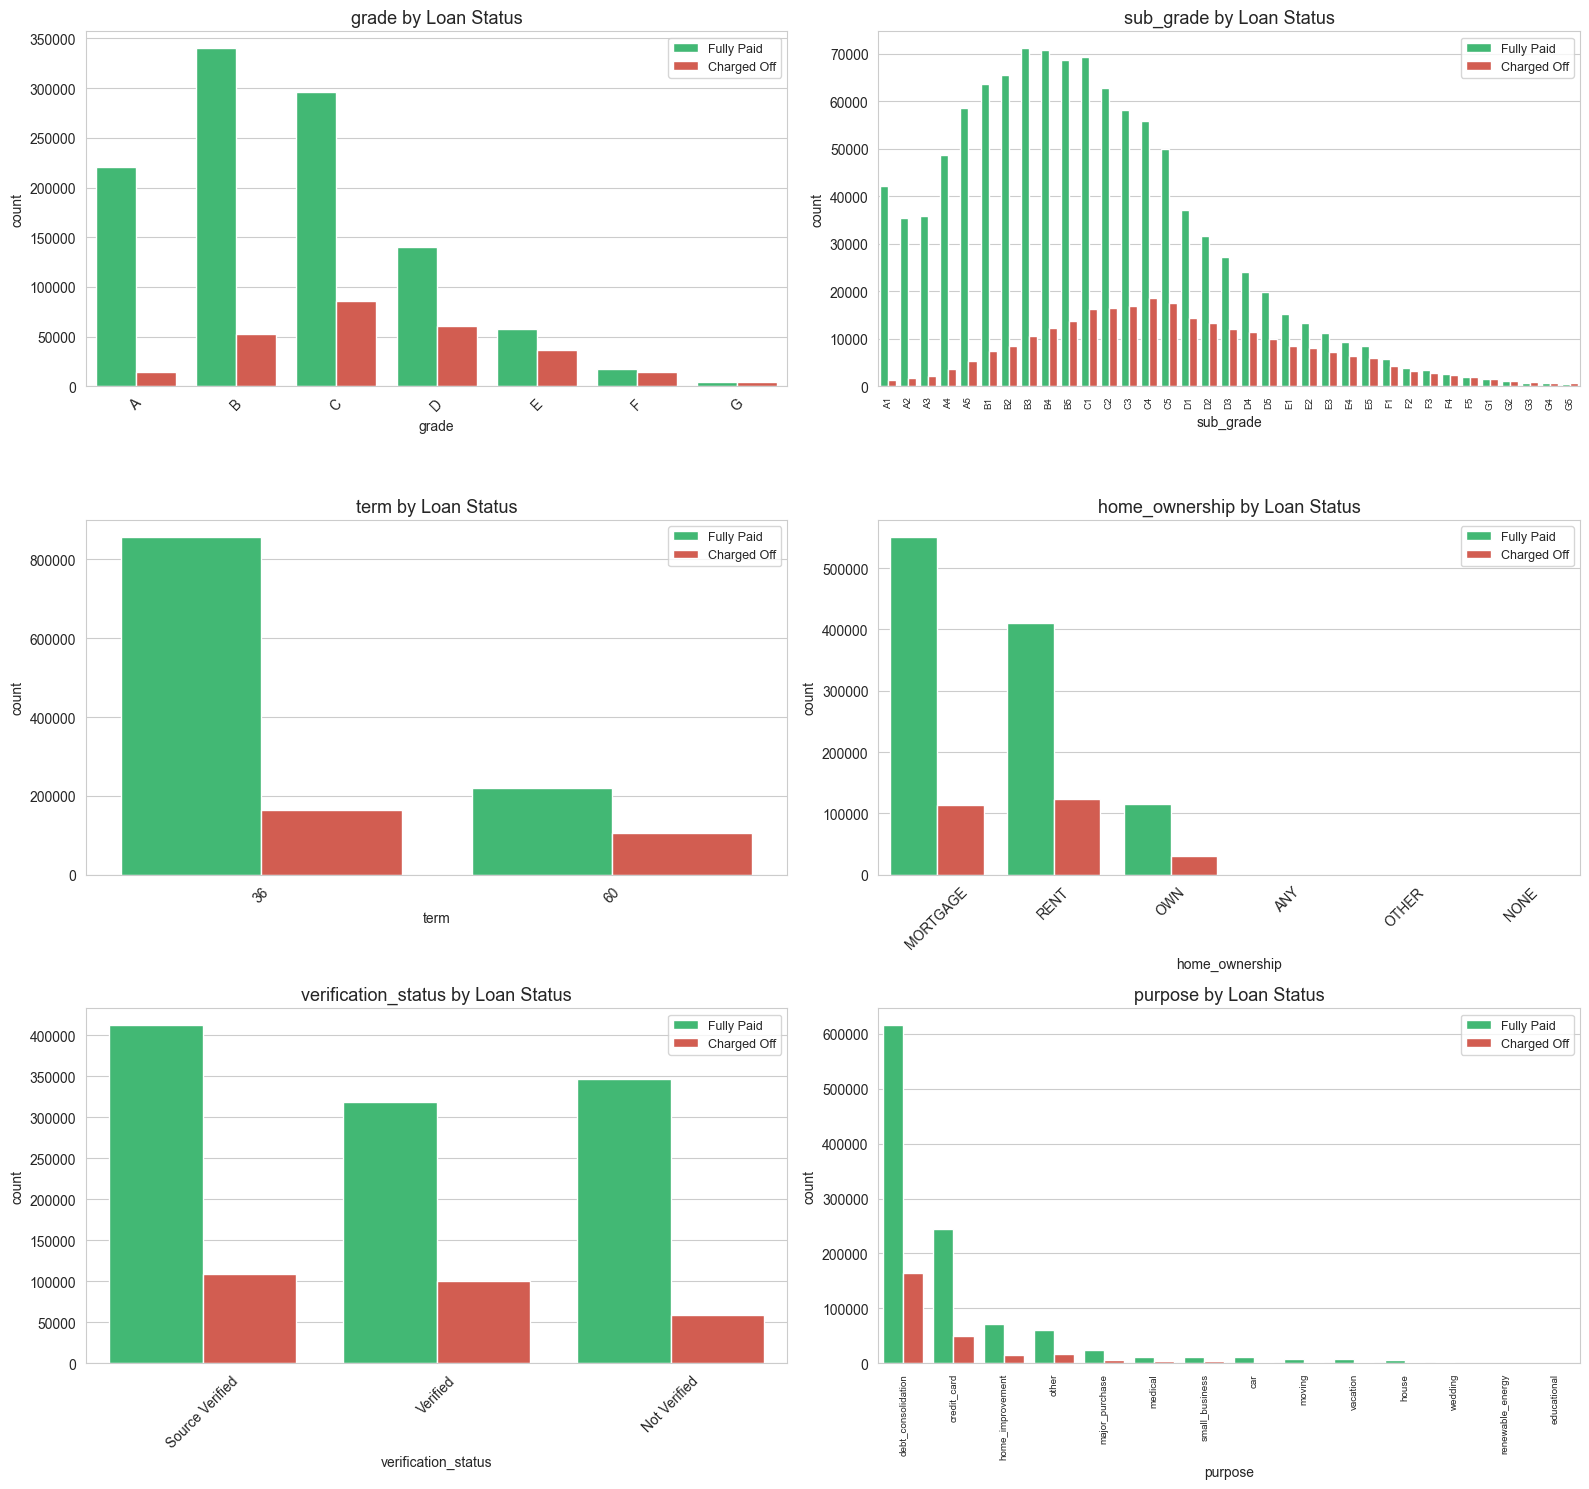

In [6]:
# Faressayah-style: countplots with hue=loan_status to show volume + composition
# Map loan_status for readable legend
df['status_label'] = df['loan_status'].map({0: 'Fully Paid', 1: 'Charged Off'})

fig, axes = plt.subplots(3, 2, figsize=(16, 15))
axes = axes.flatten()

cat_features = ['grade', 'sub_grade', 'term', 'home_ownership',
                'verification_status', 'purpose']

for i, col in enumerate(cat_features):
    if col == 'sub_grade':
        order = sorted(df[col].unique())
    elif col == 'grade':
        order = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
    elif col == 'purpose':
        order = df[col].value_counts().index
    else:
        order = df[col].value_counts().index

    sns.countplot(data=df, x=col, order=order, hue='status_label',
                  palette={'Fully Paid': '#2ecc71', 'Charged Off': '#e74c3c'},
                  ax=axes[i], edgecolor='white')
    axes[i].set_title(f'{col} by Loan Status', fontsize=13)
    if col in ['sub_grade', 'purpose']:
        axes[i].tick_params(axis='x', rotation=90, labelsize=7)
    else:
        axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='', fontsize=9)

plt.tight_layout()
plt.show()

df.drop(columns=['status_label'], inplace=True)

## 4. Bivariate Analysis — Features vs. Default

### 4.1 Default Rate by Categorical Features

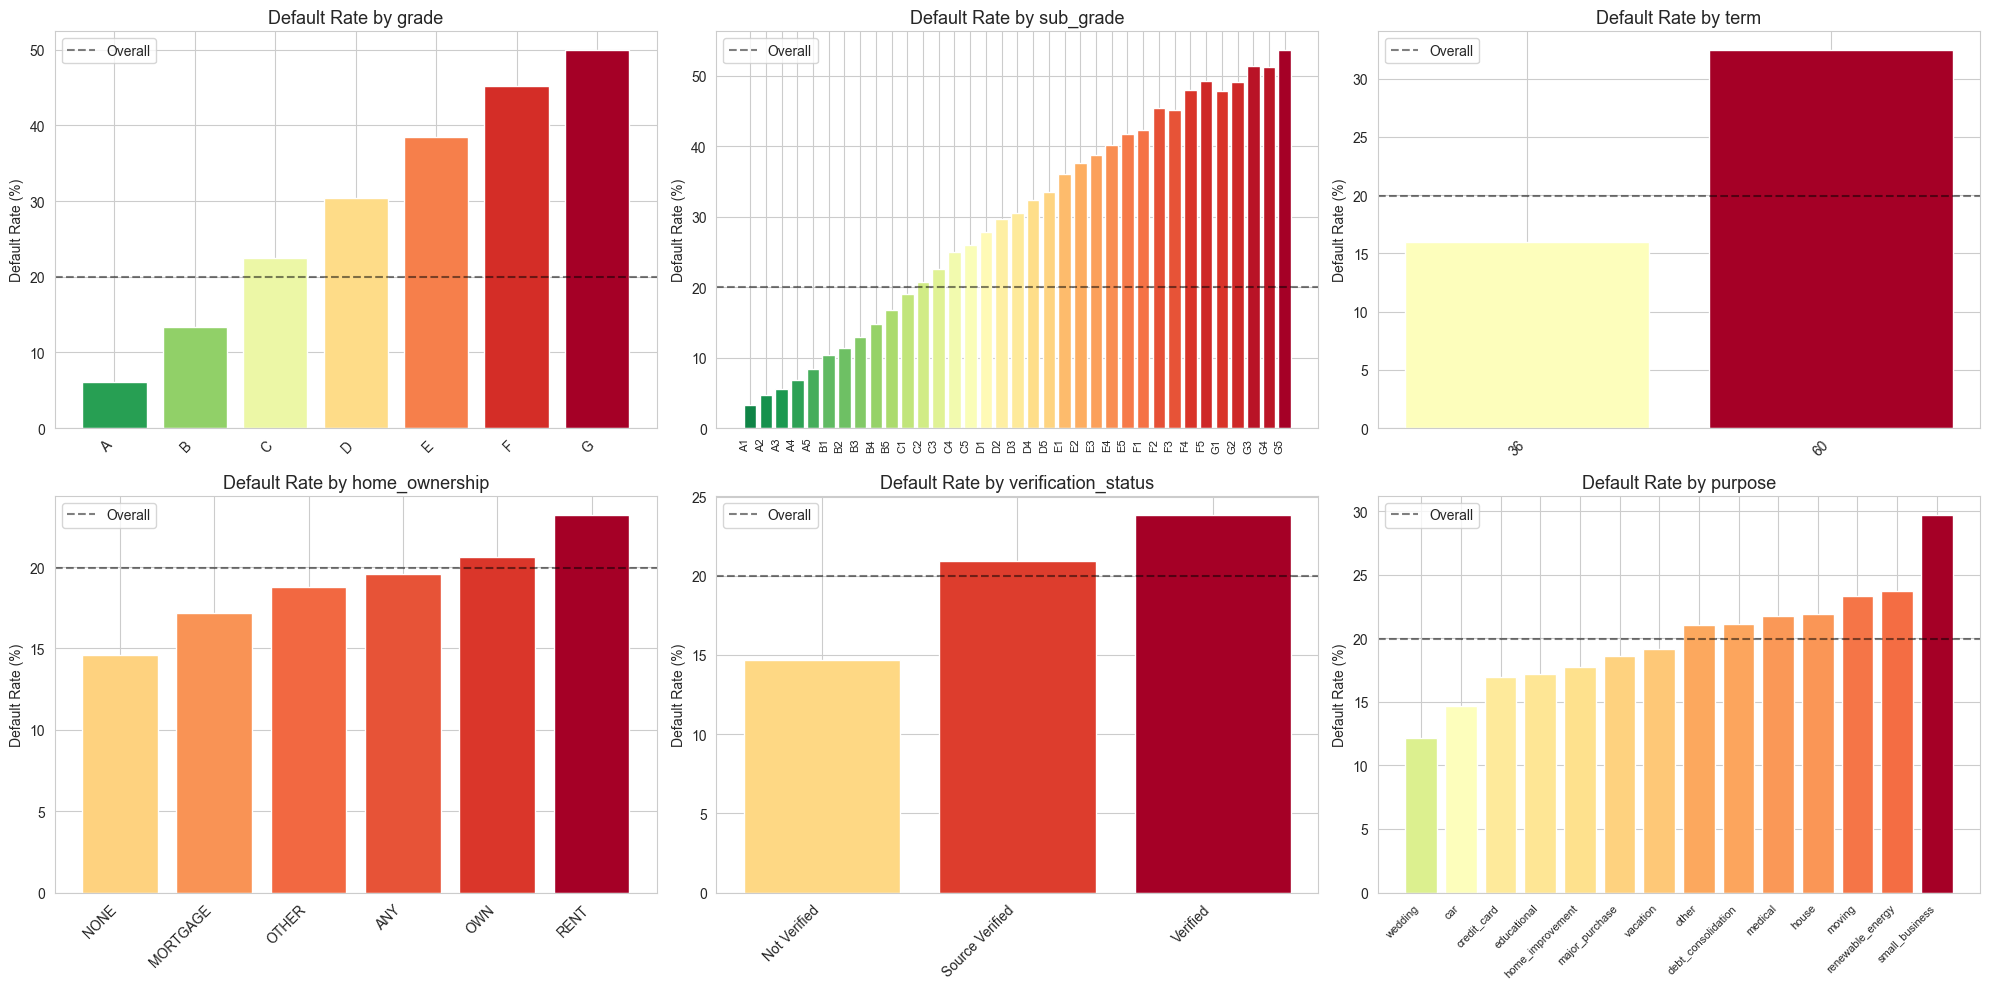

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

cat_for_default = ['grade', 'sub_grade', 'term', 'home_ownership',
                   'verification_status', 'purpose']

for i, col in enumerate(cat_for_default):
    if col == 'sub_grade':
        order = sorted(df[col].unique())
    elif col == 'grade':
        order = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
    elif col == 'purpose':
        order = df.groupby(col)['loan_status'].mean().sort_values().index
    else:
        order = df.groupby(col)['loan_status'].mean().sort_values().index
    
    default_rates = df.groupby(col)['loan_status'].mean().reindex(order) * 100
    bars = axes[i].bar(range(len(default_rates)), default_rates.values,
                       color=plt.cm.RdYlGn_r(default_rates.values / default_rates.max()),
                       edgecolor='white')
    axes[i].set_xticks(range(len(default_rates)))
    axes[i].set_xticklabels(default_rates.index, rotation=45 if col != 'sub_grade' else 90,
                            ha='right', fontsize=8 if col in ['sub_grade', 'purpose'] else 10)
    axes[i].set_title(f'Default Rate by {col}', fontsize=13)
    axes[i].set_ylabel('Default Rate (%)')
    axes[i].axhline(y=df['loan_status'].mean() * 100, color='black',
                    linestyle='--', alpha=0.5, label='Overall')
    axes[i].legend()

plt.tight_layout()
plt.show()

### 4.2 Numerical Features by Default Status

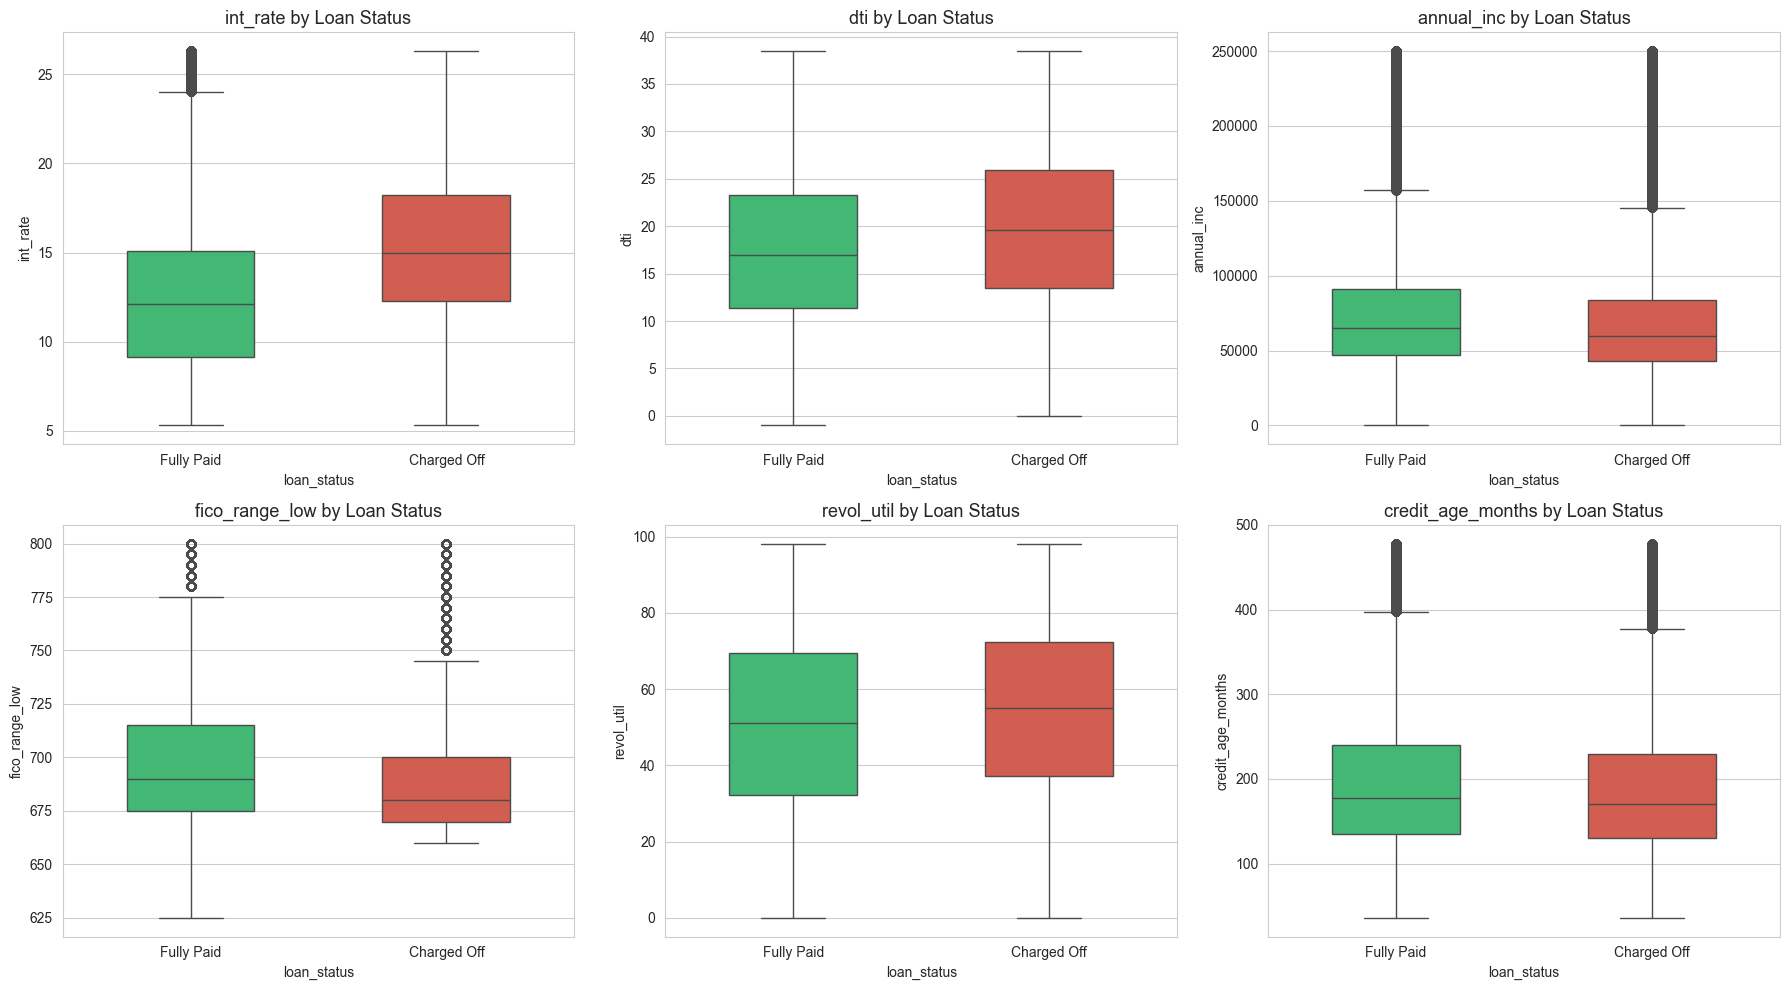

In [8]:
box_features = ['int_rate', 'dti', 'annual_inc', 'fico_range_low',
                'revol_util', 'credit_age_months']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(box_features):
    # Clip at 99th percentile for readability
    upper = df[col].quantile(0.99)
    data = df[df[col] <= upper]
    
    sns.boxplot(data=data, x='loan_status', y=col, ax=axes[i],
                palette=['#2ecc71', '#e74c3c'], width=0.5)
    axes[i].set_xticklabels(['Fully Paid', 'Charged Off'])
    axes[i].set_title(f'{col} by Loan Status', fontsize=13)

plt.tight_layout()
plt.show()

### 4.2b Overlaid Distributions by Default Status

Overlaid histograms show WHERE the distributions of defaulters vs. non-defaulters diverge — more informative than box plots alone.

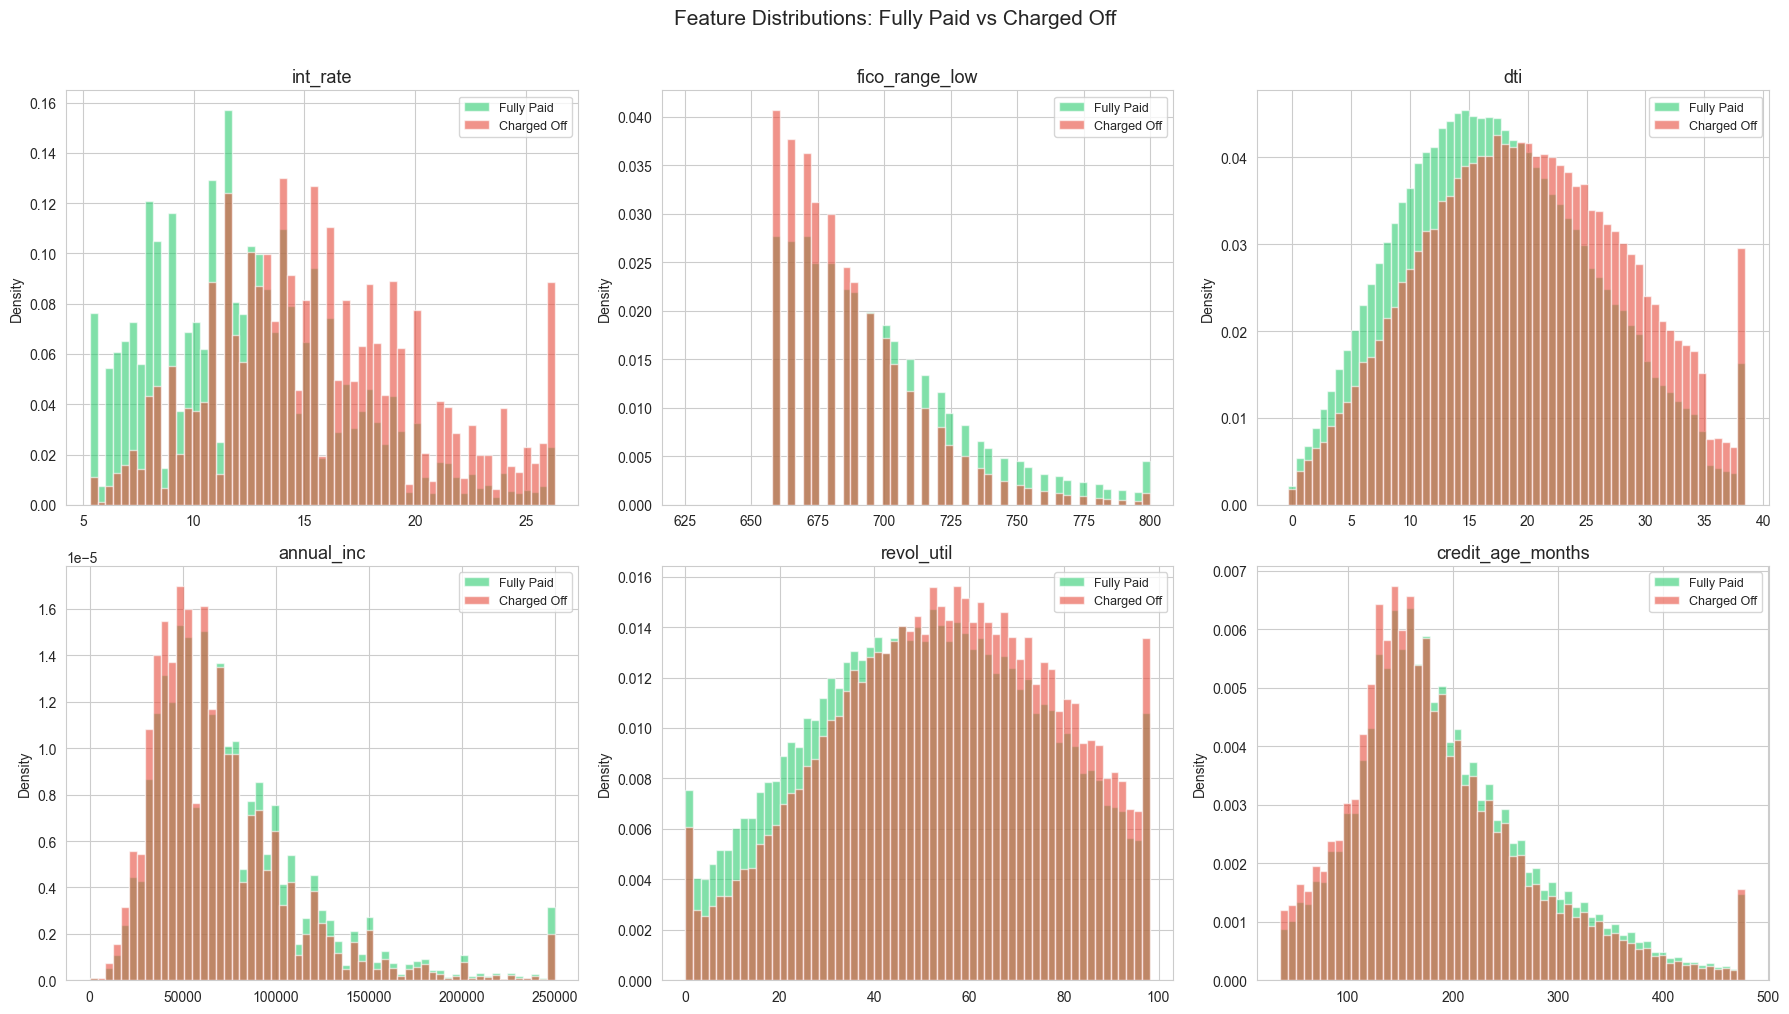

In [9]:
overlay_features = ['int_rate', 'fico_range_low', 'dti', 'annual_inc', 'revol_util', 'credit_age_months']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

fp = df[df['loan_status'] == 0]
co = df[df['loan_status'] == 1]

for i, col in enumerate(overlay_features):
    upper = df[col].quantile(0.99)
    bins = np.linspace(df[col].min(), upper, 60)

    axes[i].hist(fp[col].clip(upper=upper), bins=bins, alpha=0.6, density=True,
                 color='#2ecc71', label='Fully Paid', edgecolor='white')
    axes[i].hist(co[col].clip(upper=upper), bins=bins, alpha=0.6, density=True,
                 color='#e74c3c', label='Charged Off', edgecolor='white')
    axes[i].set_title(col, fontsize=13)
    axes[i].legend(fontsize=9)
    axes[i].set_ylabel('Density')

plt.suptitle('Feature Distributions: Fully Paid vs Charged Off', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### 4.3 Correlation Heatmap

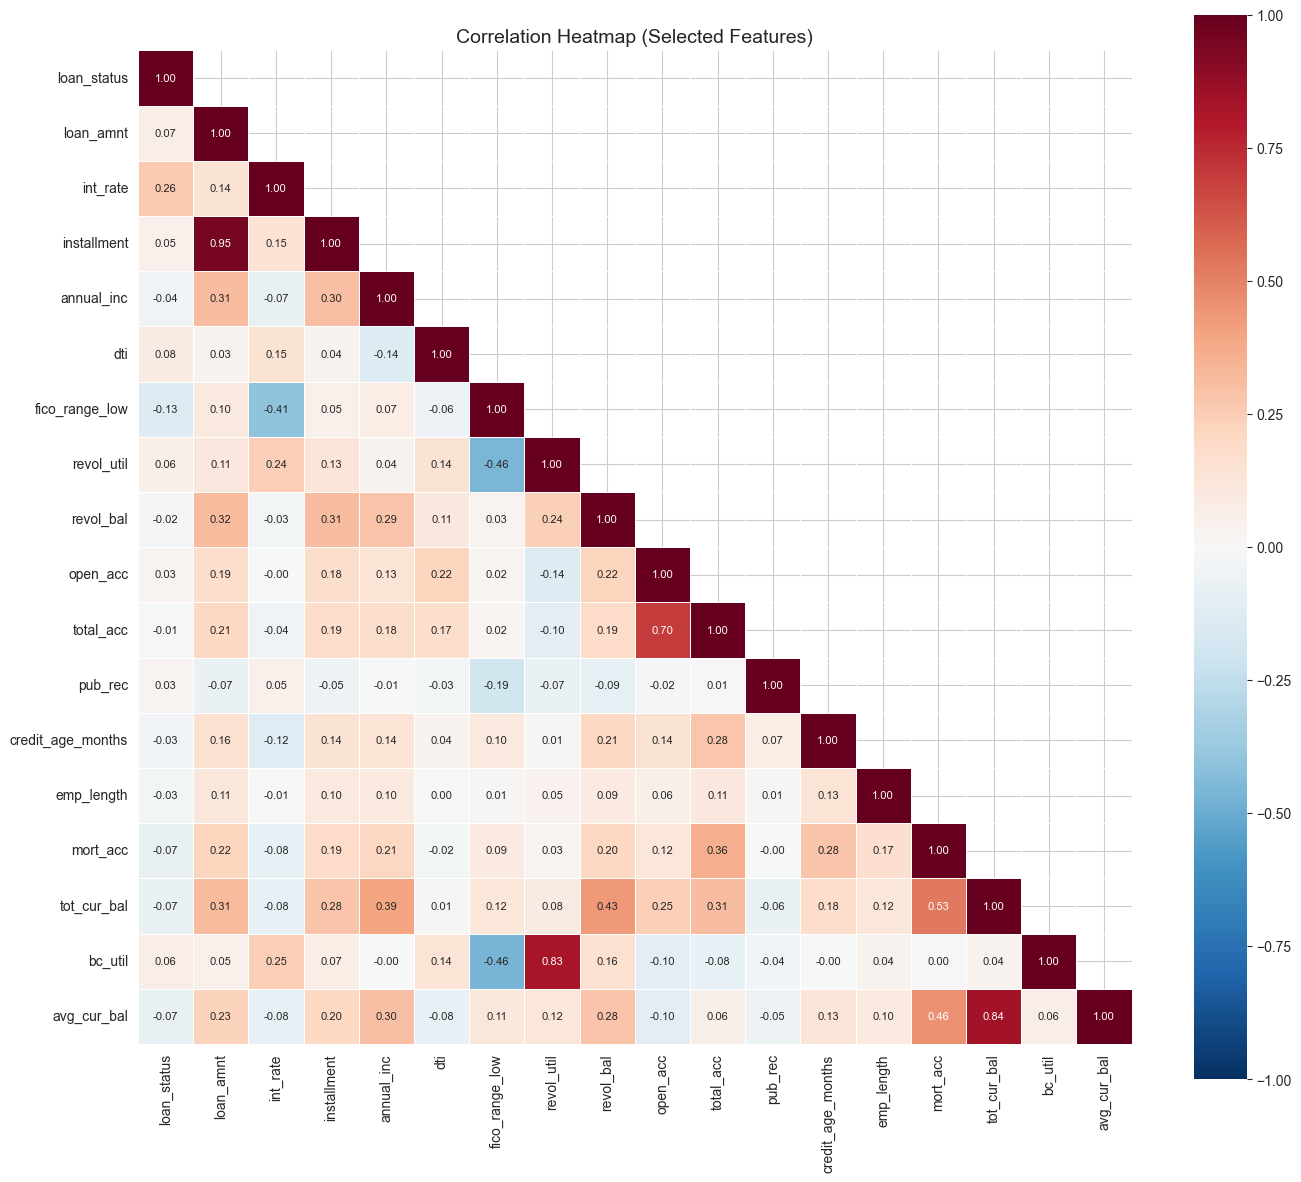

In [10]:
# Select a meaningful subset for readability
corr_cols = ['loan_status', 'loan_amnt', 'int_rate', 'installment', 'annual_inc',
             'dti', 'fico_range_low', 'revol_util', 'revol_bal', 'open_acc',
             'total_acc', 'pub_rec', 'credit_age_months', 'emp_length',
             'mort_acc', 'tot_cur_bal', 'bc_util', 'avg_cur_bal']

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            ax=ax, annot_kws={'size': 8})
ax.set_title('Correlation Heatmap (Selected Features)', fontsize=14)
plt.tight_layout()
plt.show()

### 4.3b Feature Correlation Bar Chart with Target (Faressayah-style)

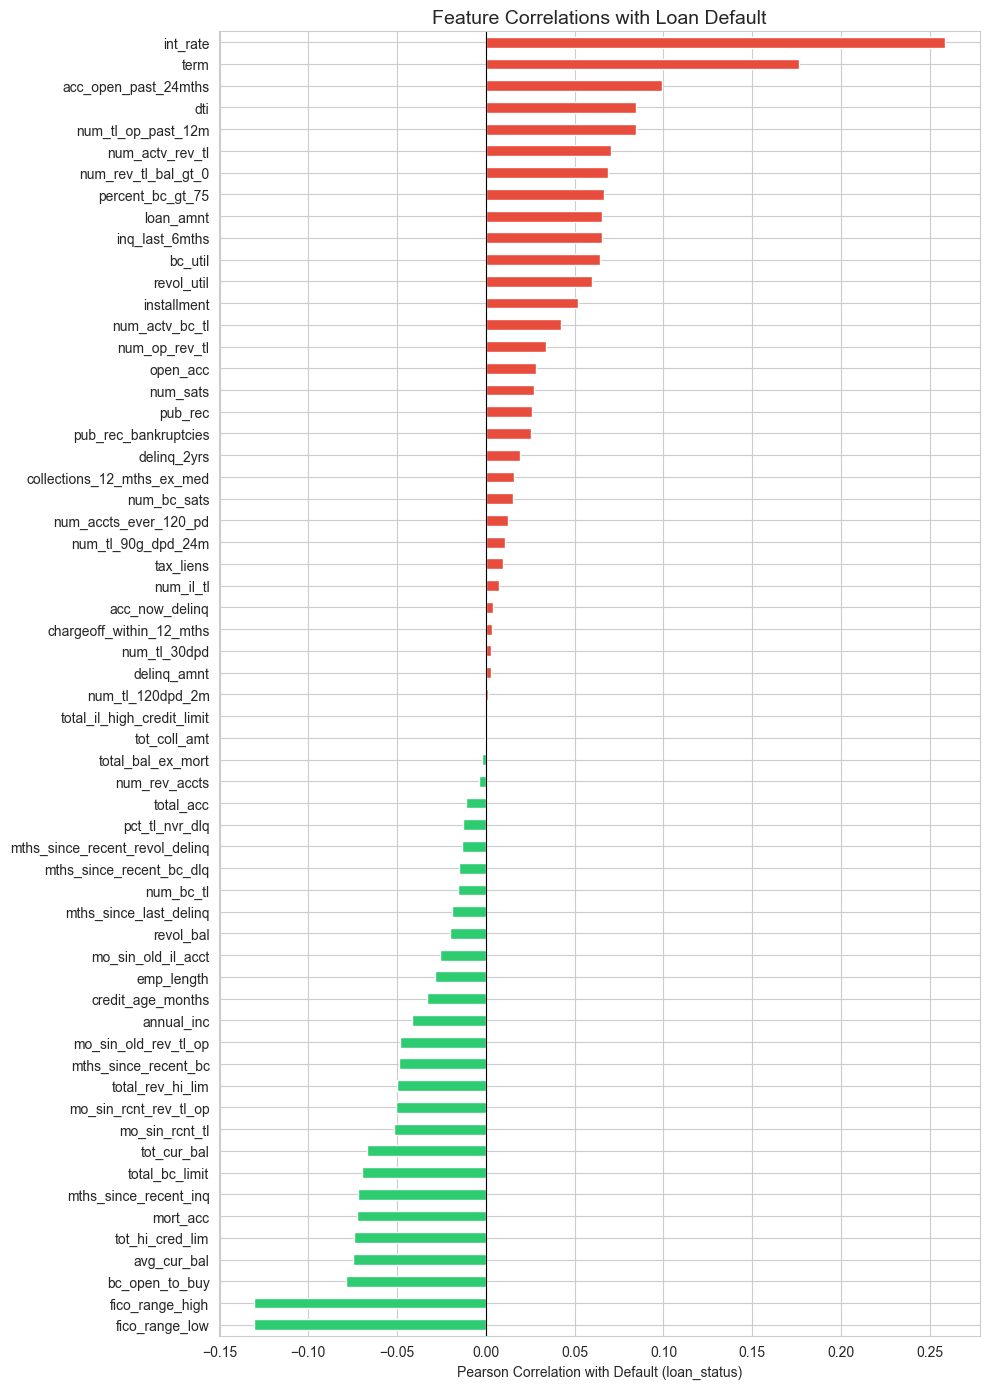

Top 10 POSITIVE correlations (higher value → more default):
int_rate                0.258792
term                    0.176096
acc_open_past_24mths    0.099427
dti                     0.084499
num_tl_op_past_12m      0.084397
num_actv_rev_tl         0.070442
num_rev_tl_bal_gt_0     0.069026
percent_bc_gt_75        0.066326
loan_amnt               0.065604
inq_last_6mths          0.065454

Top 10 NEGATIVE correlations (higher value → less default):
fico_range_low          -0.130683
fico_range_high         -0.130682
bc_open_to_buy          -0.078591
avg_cur_bal             -0.074760
tot_hi_cred_lim         -0.074505
mort_acc                -0.072468
mths_since_recent_inq   -0.071757
total_bc_limit          -0.069575
tot_cur_bal             -0.067133
mo_sin_rcnt_tl          -0.051869


In [11]:
# Sorted bar chart of ALL numeric feature correlations with target
numeric_only = df.select_dtypes(include=[np.number]).drop(columns=['loan_status'])
target_corr = numeric_only.corrwith(df['loan_status']).sort_values()

fig, ax = plt.subplots(figsize=(10, 14))
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in target_corr.values]
target_corr.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_xlabel('Pearson Correlation with Default (loan_status)')
ax.set_title('Feature Correlations with Loan Default', fontsize=14)
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

# Print top 10 positive and negative
print("Top 10 POSITIVE correlations (higher value → more default):")
print(target_corr.tail(10).iloc[::-1].to_string())
print("\nTop 10 NEGATIVE correlations (higher value → less default):")
print(target_corr.head(10).to_string())

### 4.4 Mean Comparison: Defaulters vs Non-Defaulters

In [12]:
# Quick comparison of key feature means between classes
key_features = ['int_rate', 'fico_range_low', 'dti', 'annual_inc', 'revol_util',
                'revol_bal', 'loan_amnt', 'installment', 'credit_age_months',
                'emp_length', 'open_acc', 'total_acc', 'pub_rec', 'mort_acc',
                'bc_util', 'tot_cur_bal']

comparison = pd.DataFrame({
    'Fully Paid (mean)': df[df['loan_status'] == 0][key_features].mean(),
    'Charged Off (mean)': df[df['loan_status'] == 1][key_features].mean(),
})
comparison['Difference'] = comparison['Charged Off (mean)'] - comparison['Fully Paid (mean)']
comparison['% Difference'] = (comparison['Difference'] / comparison['Fully Paid (mean)'] * 100).round(1)
comparison = comparison.sort_values('% Difference', ascending=False)

print("Key Feature Means: Defaulters vs Non-Defaulters")
print("=" * 80)
print(comparison.round(2).to_string())
print("\nPositive % diff = defaulters have HIGHER values")
print("Negative % diff = defaulters have LOWER values")

Key Feature Means: Defaulters vs Non-Defaulters
                   Fully Paid (mean)  Charged Off (mean)  Difference  % Difference
int_rate                       12.62               15.71        3.09          24.5
pub_rec                         0.21                0.25        0.04          19.0
dti                            17.81               20.17        2.36          13.2
loan_amnt                   14134.37            15565.06     1430.69          10.1
installment                   431.32              465.15       33.82           7.8
bc_util                         59.2               63.65        4.45           7.5
revol_util                     51.08               54.76        3.68           7.2
open_acc                       11.52                11.9        0.38           3.3
total_acc                      25.05               24.71       -0.34          -1.4
fico_range_low                698.26              687.85      -10.41          -1.5
credit_age_months             196.62   

### 4.5 Default Rate by State (Geographic Analysis)

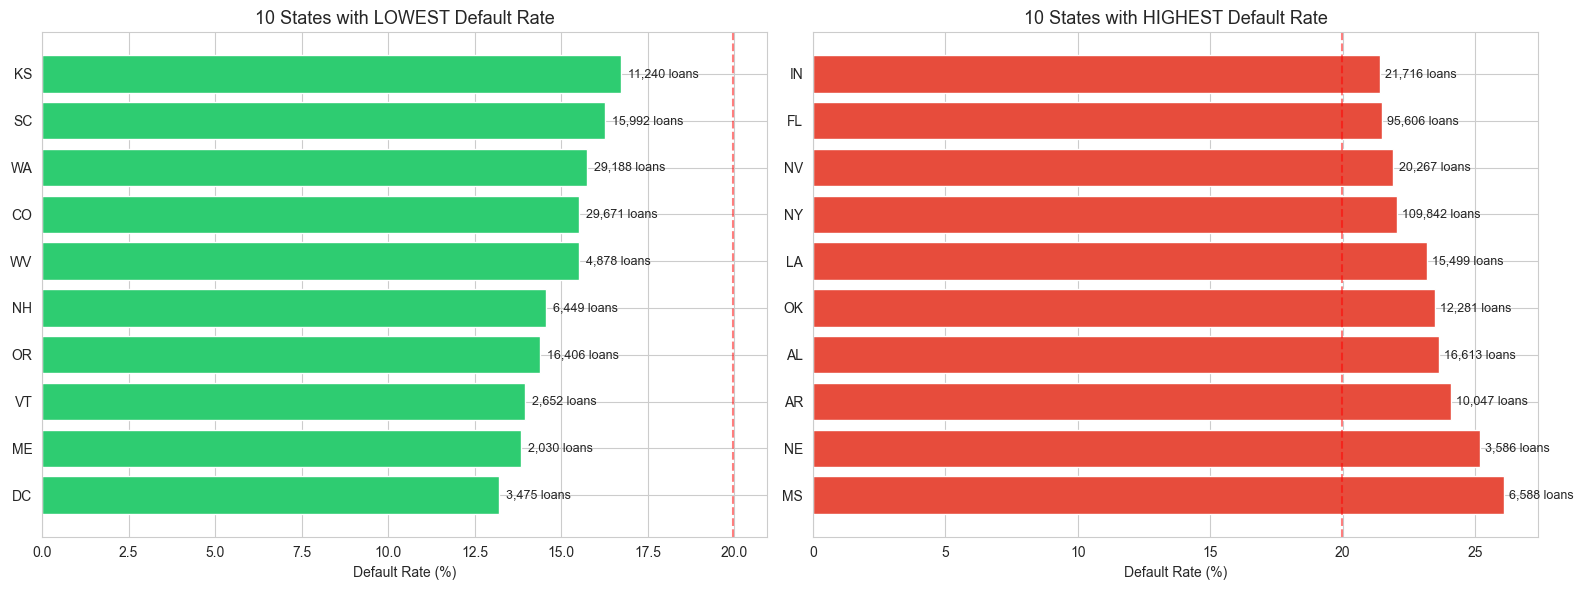

Default rate range across states: 13.2% — 26.1% (spread: 12.9pp)


In [13]:
# Default rate by state — top 15 highest and lowest
state_default = df.groupby('addr_state').agg(
    default_rate=('loan_status', 'mean'),
    count=('loan_status', 'count')
).sort_values('default_rate')

# Only states with meaningful sample size (>500 loans)
state_default = state_default[state_default['count'] >= 500]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Lowest default rate states
bottom10 = state_default.head(10)
axes[0].barh(bottom10.index, bottom10['default_rate'] * 100, color='#2ecc71', edgecolor='white')
axes[0].set_xlabel('Default Rate (%)')
axes[0].set_title('10 States with LOWEST Default Rate', fontsize=13)
axes[0].axvline(x=df['loan_status'].mean() * 100, color='red', linestyle='--', alpha=0.5)
for i, (rate, cnt) in enumerate(zip(bottom10['default_rate'], bottom10['count'])):
    axes[0].text(rate * 100 + 0.2, i, f'{cnt:,} loans', va='center', fontsize=9)

# Highest default rate states
top10 = state_default.tail(10).iloc[::-1]
axes[1].barh(top10.index, top10['default_rate'] * 100, color='#e74c3c', edgecolor='white')
axes[1].set_xlabel('Default Rate (%)')
axes[1].set_title('10 States with HIGHEST Default Rate', fontsize=13)
axes[1].axvline(x=df['loan_status'].mean() * 100, color='red', linestyle='--', alpha=0.5)
for i, (rate, cnt) in enumerate(zip(top10['default_rate'], top10['count'])):
    axes[1].text(rate * 100 + 0.2, i, f'{cnt:,} loans', va='center', fontsize=9)

plt.tight_layout()
plt.show()

spread = state_default['default_rate'].max() - state_default['default_rate'].min()
print(f"Default rate range across states: {state_default['default_rate'].min()*100:.1f}% — {state_default['default_rate'].max()*100:.1f}% (spread: {spread*100:.1f}pp)")

### 4.6 Feature Interactions: FICO vs Interest Rate

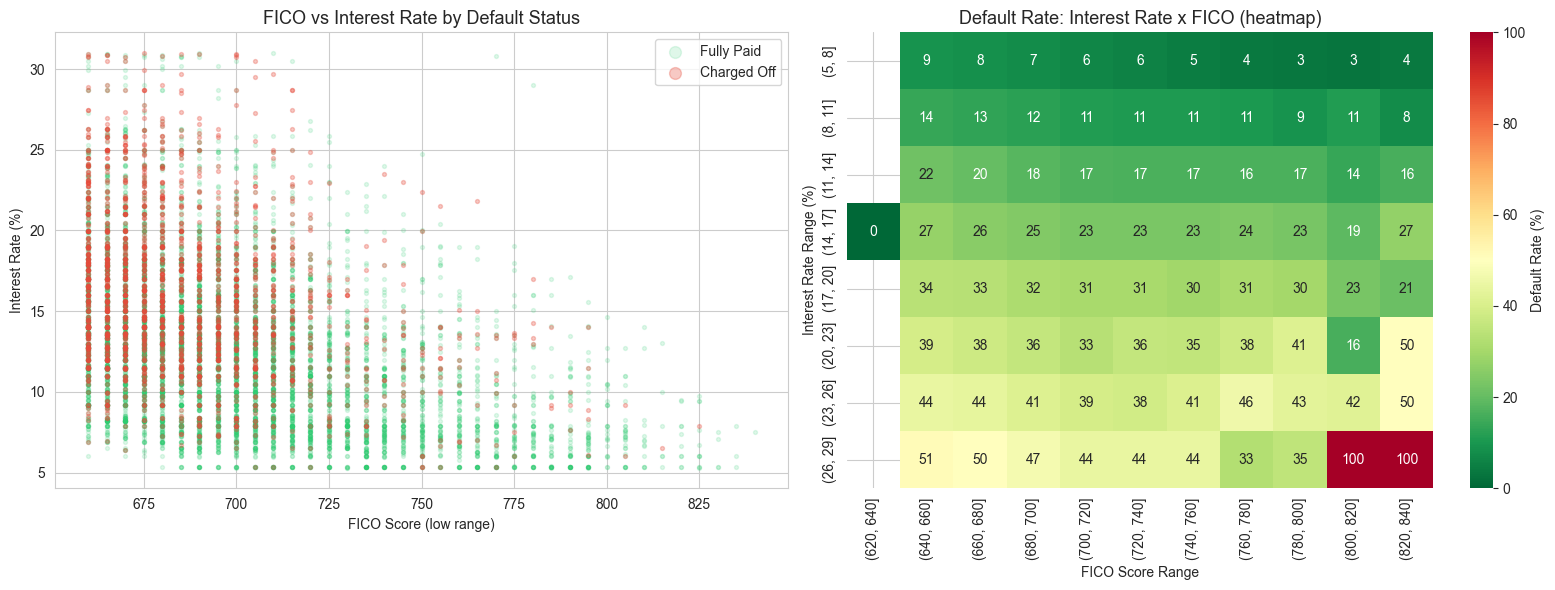

In [14]:
# FICO vs Interest Rate — the two strongest default predictors
# Use sample for scatter readability
sample_10k = df.sample(10_000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter colored by default status
fp_mask = sample_10k['loan_status'] == 0
co_mask = sample_10k['loan_status'] == 1

axes[0].scatter(sample_10k.loc[fp_mask, 'fico_range_low'],
                sample_10k.loc[fp_mask, 'int_rate'],
                c='#2ecc71', alpha=0.15, s=8, label='Fully Paid')
axes[0].scatter(sample_10k.loc[co_mask, 'fico_range_low'],
                sample_10k.loc[co_mask, 'int_rate'],
                c='#e74c3c', alpha=0.3, s=8, label='Charged Off')
axes[0].set_xlabel('FICO Score (low range)')
axes[0].set_ylabel('Interest Rate (%)')
axes[0].set_title('FICO vs Interest Rate by Default Status', fontsize=13)
axes[0].legend(markerscale=3)

# Heatmap: default rate by FICO bin x int_rate bin
df['fico_bin'] = pd.cut(df['fico_range_low'], bins=range(620, 860, 20))
df['rate_bin'] = pd.cut(df['int_rate'], bins=range(5, 32, 3))
pivot = df.pivot_table(values='loan_status', index='rate_bin', columns='fico_bin', aggfunc='mean')

sns.heatmap(pivot * 100, annot=True, fmt='.0f', cmap='RdYlGn_r', ax=axes[1],
            cbar_kws={'label': 'Default Rate (%)'})
axes[1].set_title('Default Rate: Interest Rate x FICO (heatmap)', fontsize=13)
axes[1].set_xlabel('FICO Score Range')
axes[1].set_ylabel('Interest Rate Range (%)')

plt.tight_layout()
plt.show()

df.drop(columns=['fico_bin', 'rate_bin'], inplace=True)

## 5. Comparison with Rejected Applications

The rejected dataset has only 9 columns vs. 151 in the accepted dataset, so comparison is limited to overlapping fields: **loan amount**, **DTI**, **employment length**, and **state**.

In [15]:
# Load rejected data (27.6M rows — just read what we need)
rej = pd.read_csv('data/rejected_2007_to_2018Q4.csv', low_memory=False)
print(f"Rejected dataset shape: {rej.shape}")
print(f"Columns: {list(rej.columns)}")
rej.head()

Rejected dataset shape: (27648741, 9)
Columns: ['Amount Requested', 'Application Date', 'Loan Title', 'Risk_Score', 'Debt-To-Income Ratio', 'Zip Code', 'State', 'Employment Length', 'Policy Code']


,Amount Requested,Application Date,Loan Title,Risk_Score,Debt-To-Income Ratio,Zip Code,State,Employment Length,Policy Code
0,1000.0,2007-05-26,Wedding Covered but No Honeymoon,693.0,10%,481xx,NM,4 years,0.0
1,1000.0,2007-05-26,Consolidating Debt,703.0,10%,010xx,MA,< 1 year,0.0
2,11000.0,2007-05-27,Want to consolidate my debt,715.0,10%,212xx,MD,1 year,0.0
3,6000.0,2007-05-27,waksman,698.0,38.64%,017xx,MA,< 1 year,0.0
4,1500.0,2007-05-27,mdrigo,509.0,9.43%,209xx,MD,< 1 year,0.0


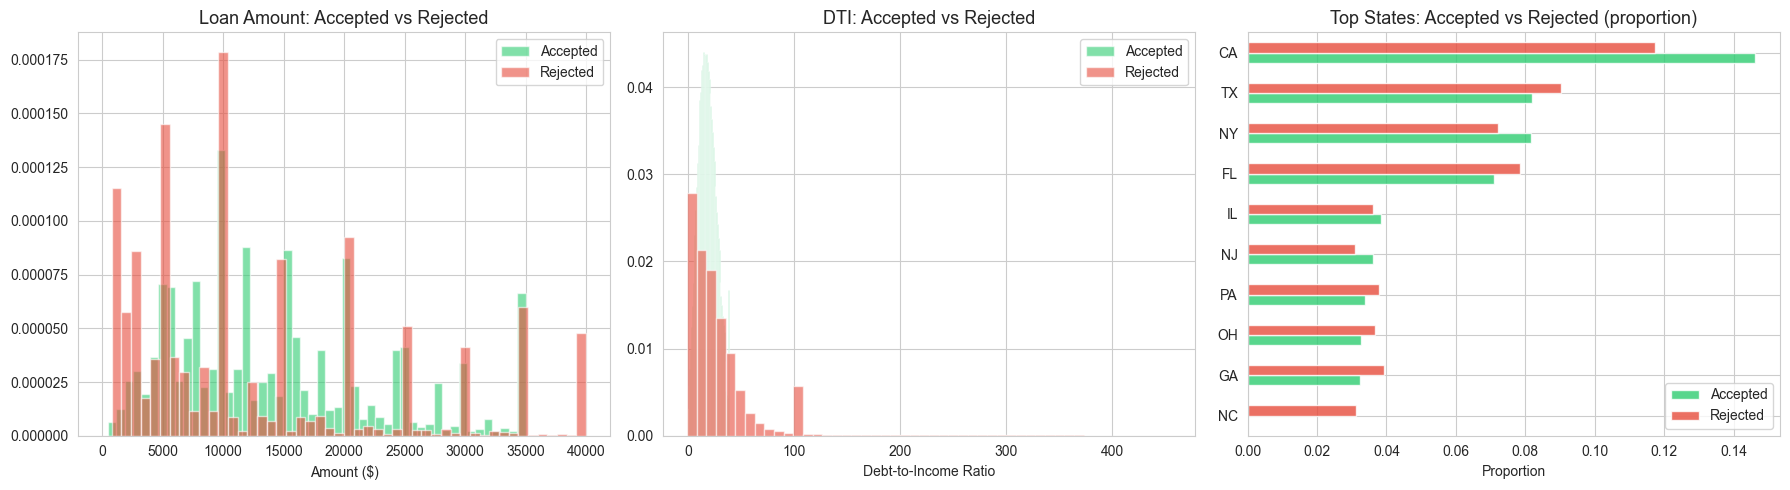


Accepted — median loan amount: $12,000, median DTI: 17.6%


Rejected — median amount requested: $10,000, median DTI: 19.7%


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Loan amount comparison
acc_amt = df['loan_amnt'].clip(upper=df['loan_amnt'].quantile(0.99))
rej_amt = pd.to_numeric(rej['Amount Requested'], errors='coerce').dropna()
rej_amt = rej_amt.clip(upper=rej_amt.quantile(0.99))

axes[0].hist(acc_amt, bins=50, alpha=0.6, label='Accepted', color='#2ecc71', density=True)
axes[0].hist(rej_amt, bins=50, alpha=0.6, label='Rejected', color='#e74c3c', density=True)
axes[0].set_title('Loan Amount: Accepted vs Rejected', fontsize=13)
axes[0].set_xlabel('Amount ($)')
axes[0].legend()

# 2. DTI comparison
acc_dti = df['dti'].clip(upper=df['dti'].quantile(0.99))
rej_dti = pd.to_numeric(rej['Debt-To-Income Ratio'].astype(str).str.rstrip('%'),
                        errors='coerce').dropna()
rej_dti = rej_dti[rej_dti <= rej_dti.quantile(0.99)]

axes[1].hist(acc_dti, bins=50, alpha=0.6, label='Accepted', color='#2ecc71', density=True)
axes[1].hist(rej_dti, bins=50, alpha=0.6, label='Rejected', color='#e74c3c', density=True)
axes[1].set_title('DTI: Accepted vs Rejected', fontsize=13)
axes[1].set_xlabel('Debt-to-Income Ratio')
axes[1].legend()

# 3. Top 10 states comparison
acc_state = df['addr_state'].value_counts(normalize=True).head(10)
rej_state = rej['State'].value_counts(normalize=True).head(10)
# Combine on shared states
states = acc_state.index.union(rej_state.index)[:10]
comp_df = pd.DataFrame({
    'Accepted': acc_state.reindex(states).fillna(0),
    'Rejected': rej_state.reindex(states).fillna(0)
}).sort_values('Accepted', ascending=True)

comp_df.plot(kind='barh', ax=axes[2], color=['#2ecc71', '#e74c3c'], alpha=0.8)
axes[2].set_title('Top States: Accepted vs Rejected (proportion)', fontsize=13)
axes[2].set_xlabel('Proportion')

plt.tight_layout()
plt.show()

print(f"\nAccepted — median loan amount: ${df['loan_amnt'].median():,.0f}, median DTI: {df['dti'].median():.1f}%")
print(f"Rejected — median amount requested: ${rej_amt.median():,.0f}, median DTI: {rej_dti.median():.1f}%")

# Free memory
del rej

## 6. Unsupervised Learning

We apply PCA, K-Means, and t-SNE to explore structure in the data without using the target label.

### 6.1 Prepare Data for Unsupervised Analysis

In [17]:
# Select numeric features only (exclude target and datetime)
exclude_cols = ['loan_status', 'issue_d']
cat_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
numeric_cols = [c for c in df.columns if c not in exclude_cols + cat_cols]

print(f"Using {len(numeric_cols)} numeric features for unsupervised learning")

# Use a stratified sample for speed (50K rows)
SAMPLE_SIZE = 50_000
np.random.seed(42)

# Stratified sample preserving default rate
idx_0 = df[df['loan_status'] == 0].sample(int(SAMPLE_SIZE * 0.8), random_state=42).index
idx_1 = df[df['loan_status'] == 1].sample(int(SAMPLE_SIZE * 0.2), random_state=42).index
sample_idx = idx_0.union(idx_1)

X_sample = df.loc[sample_idx, numeric_cols].values.astype(np.float64)
y_sample = df.loc[sample_idx, 'loan_status'].values

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sample)

print(f"Sample shape: {X_scaled.shape}")
print(f"Sample default rate: {y_sample.mean():.2%}")

Using 60 numeric features for unsupervised learning


Sample shape: (50000, 60)
Sample default rate: 20.00%


### 6.2 PCA — Principal Component Analysis

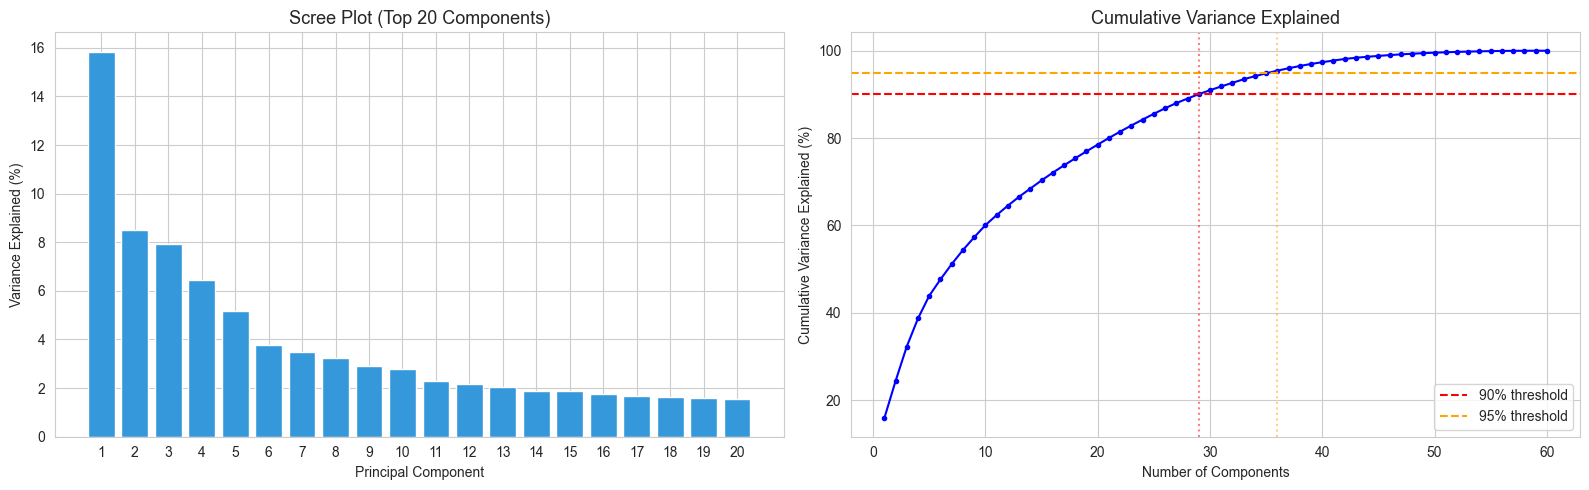

Components for 90% variance: 29
Components for 95% variance: 36


In [18]:
# Full PCA to see variance explained
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scree plot
axes[0].bar(range(1, 21), pca_full.explained_variance_ratio_[:20] * 100,
            color='#3498db', edgecolor='white')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_title('Scree Plot (Top 20 Components)', fontsize=13)
axes[0].set_xticks(range(1, 21))

# Cumulative variance
axes[1].plot(range(1, len(cumvar) + 1), cumvar, 'b-o', markersize=3)
axes[1].axhline(y=90, color='red', linestyle='--', label='90% threshold')
axes[1].axhline(y=95, color='orange', linestyle='--', label='95% threshold')
n_90 = np.argmax(cumvar >= 90) + 1
n_95 = np.argmax(cumvar >= 95) + 1
axes[1].axvline(x=n_90, color='red', linestyle=':', alpha=0.5)
axes[1].axvline(x=n_95, color='orange', linestyle=':', alpha=0.5)
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained (%)')
axes[1].set_title('Cumulative Variance Explained', fontsize=13)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Components for 90% variance: {n_90}")
print(f"Components for 95% variance: {n_95}")

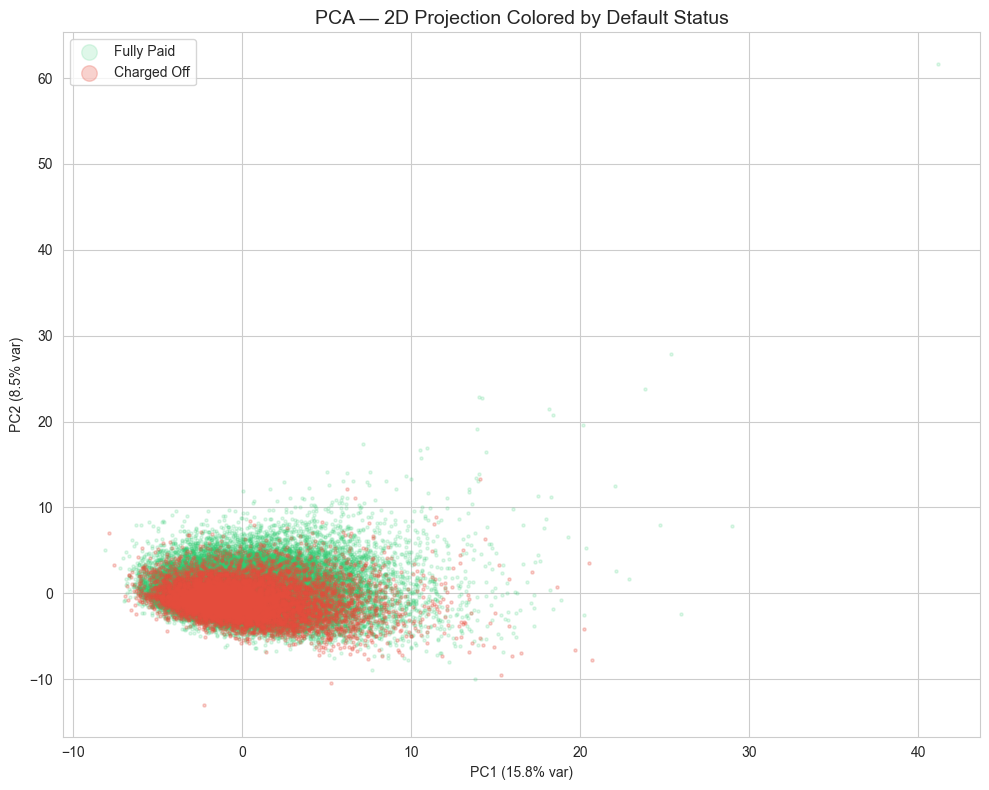


Top features contributing to PC1:
num_sats               0.269244
open_acc               0.268999
num_op_rev_tl          0.265704
num_rev_accts          0.247751
num_bc_sats            0.244234
total_acc              0.240628
num_bc_tl              0.233083
num_actv_rev_tl        0.227500
num_rev_tl_bal_gt_0    0.226023
num_actv_bc_tl         0.215732

Top features contributing to PC2:
fico_range_low          0.299500
fico_range_high         0.299500
avg_cur_bal             0.236910
tot_hi_cred_lim         0.222227
tot_cur_bal             0.213105
total_bc_limit          0.196305
total_rev_hi_lim        0.196273
bc_open_to_buy          0.177884
acc_open_past_24mths    0.173392
int_rate                0.172226


In [19]:
# 2D PCA scatter colored by default status
pca_2d = PCA(n_components=2, random_state=42)
X_pca = pca_2d.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(X_pca[y_sample == 0, 0], X_pca[y_sample == 0, 1],
                     c='#2ecc71', alpha=0.15, s=5, label='Fully Paid')
scatter = ax.scatter(X_pca[y_sample == 1, 0], X_pca[y_sample == 1, 1],
                     c='#e74c3c', alpha=0.25, s=5, label='Charged Off')
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title('PCA — 2D Projection Colored by Default Status', fontsize=14)
ax.legend(markerscale=5)
plt.tight_layout()
plt.show()

# Top contributing features to PC1 and PC2
pc_loadings = pd.DataFrame(
    pca_2d.components_.T, index=numeric_cols, columns=['PC1', 'PC2']
)
print("\nTop features contributing to PC1:")
print(pc_loadings['PC1'].abs().sort_values(ascending=False).head(10).to_string())
print("\nTop features contributing to PC2:")
print(pc_loadings['PC2'].abs().sort_values(ascending=False).head(10).to_string())

### 6.3 K-Means Clustering

  k=2: inertia=2,708,171


  k=3: inertia=2,582,487


  k=4: inertia=2,492,106


  k=5: inertia=2,404,804


  k=6: inertia=2,329,915


  k=7: inertia=2,273,784


  k=8: inertia=2,226,043


  k=9: inertia=2,183,621


  k=10: inertia=2,133,370


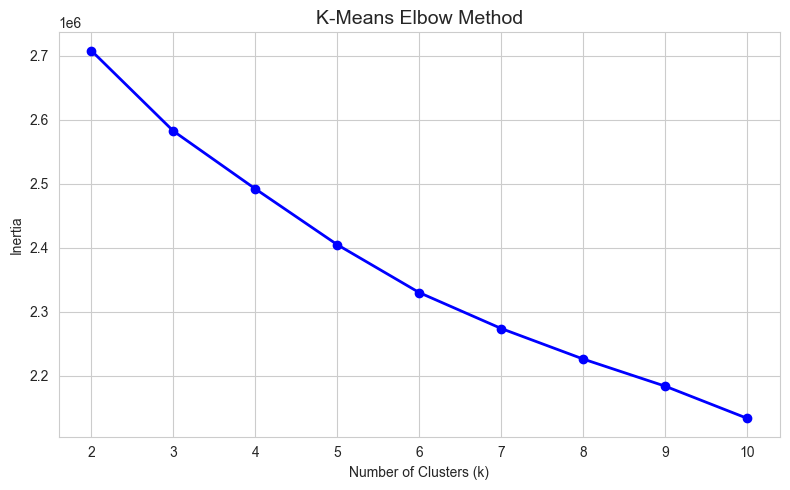

In [20]:
# Elbow method to find optimal k
inertias = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    print(f"  k={k}: inertia={km.inertia_:,.0f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(K_range, inertias, 'bo-', linewidth=2)
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia')
ax.set_title('K-Means Elbow Method', fontsize=14)
ax.set_xticks(list(K_range))
plt.tight_layout()
plt.show()

Cluster Profiles:
         count  default_rate  avg_int_rate  avg_annual_inc  avg_dti  avg_fico  avg_loan_amnt  avg_revol_util
cluster                                                                                                     
0          206          21.0         14.50        92272.66    18.97    677.16       14845.39           44.93
1         7685          11.0         10.54       119420.35    17.96    730.53       21148.81           43.46
2         8466          26.0         14.16        84655.97    22.13    688.78       17003.43           49.06
3        21396          20.0         13.43        59312.01    17.31    696.59       11797.74           54.59
4        12247          21.0         13.92        73863.44    17.34    679.45       13182.15           54.03


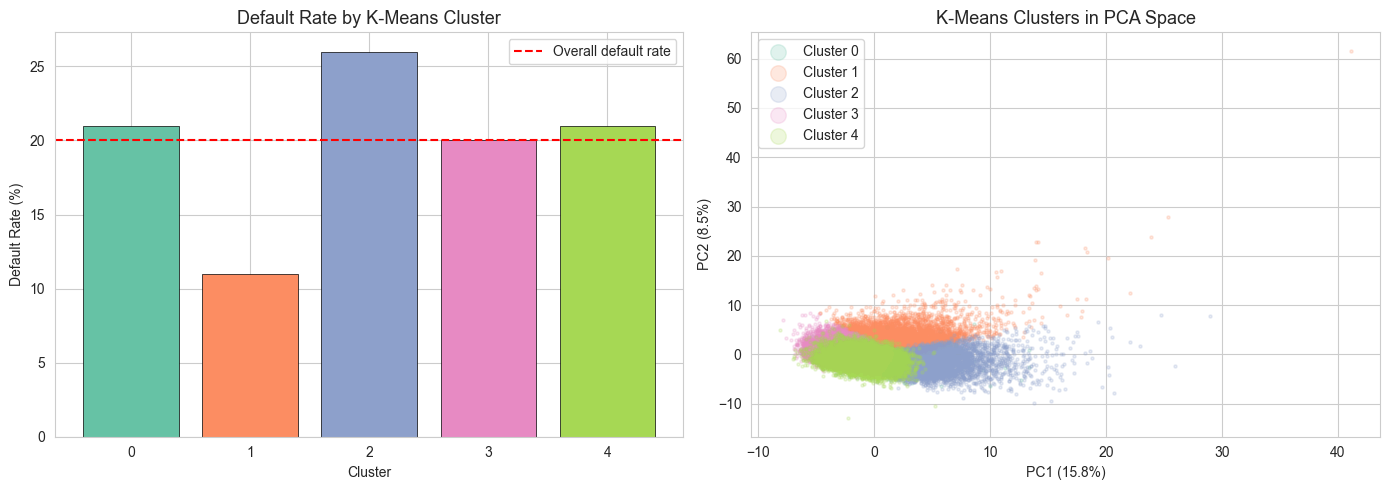

In [21]:
# Fit with chosen k (typically 4-5 from elbow)
OPTIMAL_K = 5
km_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
clusters = km_final.fit_predict(X_scaled)

# Cluster profiles
sample_df = df.loc[sample_idx].copy()
sample_df['cluster'] = clusters

# Default rate by cluster
cluster_stats = sample_df.groupby('cluster').agg(
    count=('loan_status', 'count'),
    default_rate=('loan_status', 'mean'),
    avg_int_rate=('int_rate', 'mean'),
    avg_annual_inc=('annual_inc', 'mean'),
    avg_dti=('dti', 'mean'),
    avg_fico=('fico_range_low', 'mean'),
    avg_loan_amnt=('loan_amnt', 'mean'),
    avg_revol_util=('revol_util', 'mean'),
).round(2)

cluster_stats['default_rate'] = (cluster_stats['default_rate'] * 100).round(1)
print("Cluster Profiles:")
print(cluster_stats.to_string())

# Visualize default rate by cluster
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = plt.cm.Set2(range(OPTIMAL_K))
axes[0].bar(range(OPTIMAL_K), cluster_stats['default_rate'],
            color=colors, edgecolor='black', linewidth=0.5)
axes[0].axhline(y=sample_df['loan_status'].mean() * 100, color='red',
                linestyle='--', label='Overall default rate')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Default Rate (%)')
axes[0].set_title('Default Rate by K-Means Cluster', fontsize=13)
axes[0].legend()

# PCA scatter colored by cluster
for c in range(OPTIMAL_K):
    mask = clusters == c
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], c=[colors[c]],
                    alpha=0.2, s=5, label=f'Cluster {c}')
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('K-Means Clusters in PCA Space', fontsize=13)
axes[1].legend(markerscale=5)

plt.tight_layout()
plt.show()

### 6.4 t-SNE Visualization

Running t-SNE on 10,000 samples...


t-SNE complete.


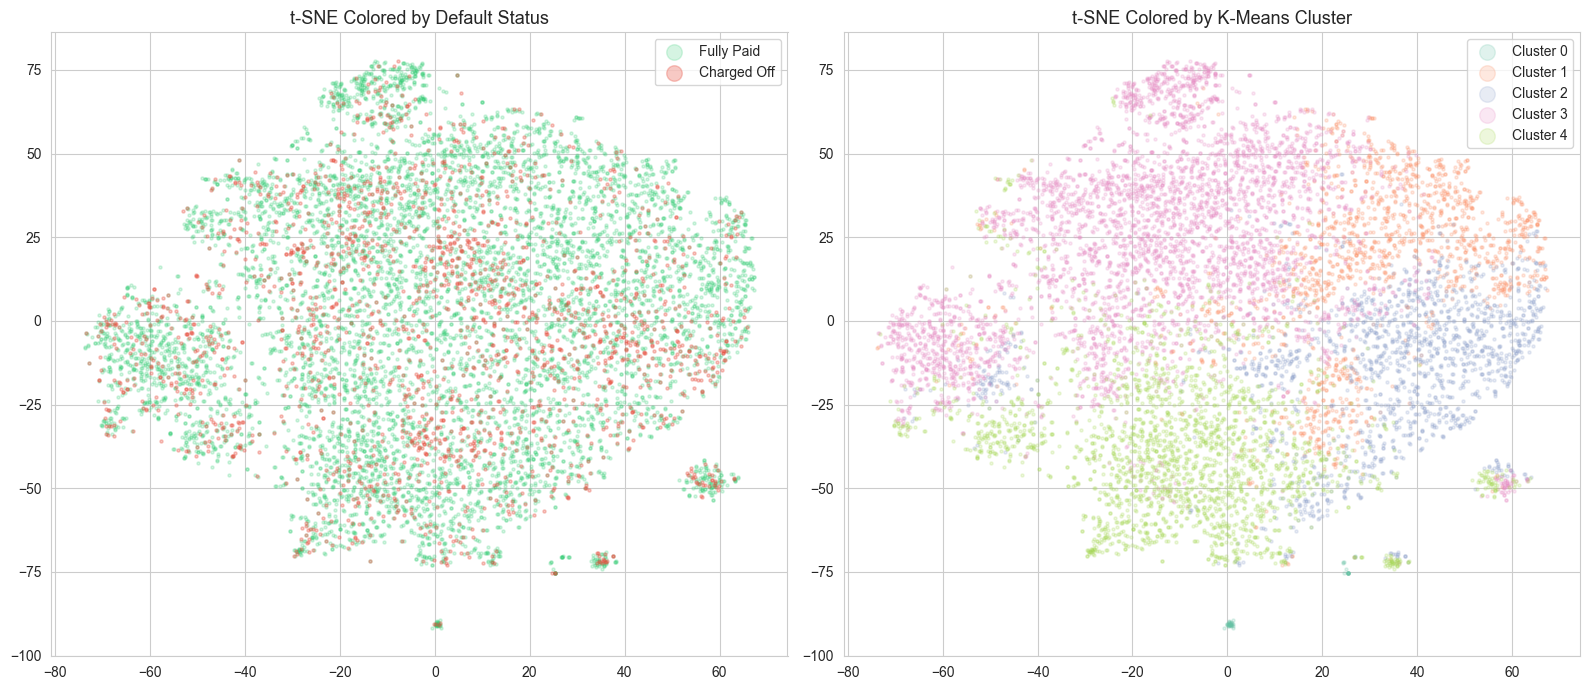

In [22]:
# t-SNE on a smaller subsample (10K) for speed
TSNE_SAMPLE = 10_000
tsne_idx = np.random.RandomState(42).choice(len(X_scaled), size=TSNE_SAMPLE, replace=False)

X_tsne_input = X_scaled[tsne_idx]
y_tsne = y_sample[tsne_idx]
clusters_tsne = clusters[tsne_idx]

print(f"Running t-SNE on {TSNE_SAMPLE:,} samples...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000, learning_rate='auto')
X_tsne = tsne.fit_transform(X_tsne_input)
print("t-SNE complete.")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Colored by default status
axes[0].scatter(X_tsne[y_tsne == 0, 0], X_tsne[y_tsne == 0, 1],
                c='#2ecc71', alpha=0.2, s=5, label='Fully Paid')
axes[0].scatter(X_tsne[y_tsne == 1, 0], X_tsne[y_tsne == 1, 1],
                c='#e74c3c', alpha=0.3, s=5, label='Charged Off')
axes[0].set_title('t-SNE Colored by Default Status', fontsize=13)
axes[0].legend(markerscale=5)

# Colored by K-Means cluster
for c in range(OPTIMAL_K):
    mask = clusters_tsne == c
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=[colors[c]],
                    alpha=0.2, s=5, label=f'Cluster {c}')
axes[1].set_title('t-SNE Colored by K-Means Cluster', fontsize=13)
axes[1].legend(markerscale=5)

plt.tight_layout()
plt.show()

## 8. Key Insights Summary

### Target Variable
- **Default rate is ~20%** (80/20 class imbalance) — class weights in the loss function preferred over SMOTE for model training (preserves probability calibration).
- Default rate varies over time with increasing loan volume, suggesting temporal patterns — temporal train/test split (pre-2016 / 2016+) is appropriate.

### Strongest Predictors of Default
- **Interest rate** — most linearly correlated with default; higher rates = higher default risk (grades D-G). Defaulters average ~3pp higher rates.
- **Grade / sub_grade** — monotonic increase in default rate from A (~5%) to G (~35%+). Grade encodes LendingClub's own risk assessment.
- **FICO score** — lower FICO = higher default. Overlaid distributions show clear leftward shift for defaulters.
- **Term** — 60-month loans default at ~2x the rate of 36-month loans.
- **DTI** — higher debt-to-income ratios correlate with default.
- **FICO x int_rate interaction** — high interest rate + low FICO borrowers have extreme default rates (40%+), confirming these features are complementary, not redundant.

### Geographic Patterns
- Default rates vary by state (~5pp spread), but the signal is moderate. Target encoding or binning may capture this better than 50 dummy columns.

### Feature Engineering Implications
- `fico_range_low` and `fico_range_high` are redundant (always 4 apart) — merge into single `fico_avg`.
- `annual_inc` and `revol_bal` are heavily right-skewed — log-transform recommended.
- `home_ownership` rare categories (ANY, NONE, OTHER) should be consolidated.
- `addr_state` (50 categories) — target encoding or grouping by default rate is preferable to one-hot.

### Unsupervised Learning Findings
- **PCA**: First ~29 components explain 90% of variance. No clear linear separation between default/non-default in 2D PCA space — consistent with this being a genuinely hard classification problem.
- **K-Means**: Clusters differ meaningfully in default rate, income, and FICO — the data has natural structure that partially aligns with risk.
- **t-SNE**: Local neighborhoods show some default-status grouping, but extensive mixing confirms that features overlap substantially between classes.

### Rejected vs. Accepted Comparison
- Rejected applicants request similar loan amounts but have higher DTI ratios.
- Geographic distribution is similar across both pools.
- Limited overlap in available columns (9 vs. 151) restricts deeper comparison.